# F1 Pit Stop Prediction — Training Framework

Binary classification: predict `PitNextLap` (whether the driver pits on the next lap).

Pipeline: load → EDA → preprocess → CV training → submission.

EDA lives in `eda.ipynb`. This notebook covers feature engineering, cross-validated training, and submission.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

import lightgbm as lgb

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_DIR = Path('.')

## 1. Load data

In [4]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'PitNextLap'
ID_COL = 'id'

print('train:', train.shape, '| test:', test.shape)
train.head()

train: (439140, 16) | test: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. Feature engineering

In [7]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    #df['IsLateRace'] = (df['RaceProgress'] > 0.7).astype(int)
    return df

train_fe = add_features(train)
test_fe = add_features(test)

CAT_COLS = ['Driver', 'Compound', 'Race']
DROP_COLS = [ID_COL, TARGET, 'LapNumber']
FEATURES = [c for c in train_fe.columns if c not in DROP_COLS]

for c in CAT_COLS:
    train_fe[c] = train_fe[c].astype('category')
    test_fe[c] = test_fe[c].astype('category')

print(f'{len(FEATURES)} features')

13 features


## 4. Cross-validation training

Group by `(Race, Year, Driver)` so the same stint doesn't leak across folds.

In [8]:
X = train_fe[FEATURES]
y = train_fe[TARGET]
groups = (train_fe['Race'].astype(str) + '_' + train_fe['Year'].astype(str) + '_' + train_fe['Driver'].astype(str))
X_test = test_fe[FEATURES]

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,
    'verbose': -1,
    'seed': RANDOM_STATE,
}

N_SPLITS = 5
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof = np.zeros(len(train_fe))
test_pred = np.zeros(len(test_fe))
feat_importance = pd.DataFrame(index=FEATURES)

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
    dtr = lgb.Dataset(X.iloc[tr_idx], y.iloc[tr_idx], categorical_feature=CAT_COLS)
    dva = lgb.Dataset(X.iloc[va_idx], y.iloc[va_idx], categorical_feature=CAT_COLS)
    model = lgb.train(
        params, dtr,
        num_boost_round=3000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
    )
    oof[va_idx] = model.predict(X.iloc[va_idx])
    test_pred += model.predict(X_test) / N_SPLITS
    feat_importance[f'fold{fold}'] = model.feature_importance(importance_type='gain')
    print(f'Fold {fold} AUC = {roc_auc_score(y.iloc[va_idx], oof[va_idx]):.5f}')

print('\nOOF AUC :', roc_auc_score(y, oof))
print('OOF AP  :', average_precision_score(y, oof))
print('OOF LL  :', log_loss(y, oof))

Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.940548
[400]	valid_0's auc: 0.941341
[600]	valid_0's auc: 0.941688
Early stopping, best iteration is:
[633]	valid_0's auc: 0.941806
Fold 0 AUC = 0.94181
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.93869
[400]	valid_0's auc: 0.939736
[600]	valid_0's auc: 0.940125
[800]	valid_0's auc: 0.940133
Early stopping, best iteration is:
[733]	valid_0's auc: 0.940227
Fold 1 AUC = 0.94023
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.938081
[400]	valid_0's auc: 0.939158
[600]	valid_0's auc: 0.93982
Early stopping, best iteration is:
[633]	valid_0's auc: 0.939886
Fold 2 AUC = 0.93989
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.94004
[400]	valid_0's auc: 0.940704
[600]	valid_0's auc: 0.941178
[800]	valid_0's auc: 0.941303
Early stopping, best iteration is:
[789]	valid_0's auc: 0.941337
Fold 3 AUC =

## 5. Feature importance

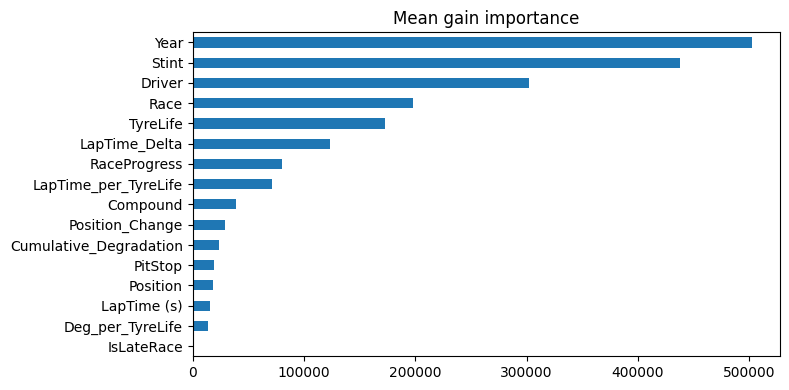

In [42]:
imp = feat_importance.mean(axis=1).sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(imp) * 0.25))); imp.plot.barh(); plt.title('Mean gain importance'); plt.tight_layout(); plt.show()

## 6. Submission

In [43]:
submission = sample_submission.copy()
submission[TARGET] = test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,PitNextLap
0,439140,0.006470
1,439141,0.003770
2,439142,0.006739
3,439143,0.134197
4,439144,0.830831
